In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import os
from PIL import Image
from sklearn.neighbors import NearestNeighbors
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from __future__ import print_function
#%matplotlib inline
import argparse
import os
import time
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

# image directory
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
# get 10 images
image_files = os.listdir(image_dir)[:10]

for i, file_name in enumerate(image_files, 1):
    # iterate over the image files that get and
    # join the path to open each image
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}") 

Random Seed:  999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


In [3]:
meta_dir = "/kaggle/input/isic-2024-challenge/"

# read the csv file
df = pd.read_csv(meta_dir + "train-metadata.csv")

# display head
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [4]:
# for training the encoder we need only positive cases
# so others are drop by the dataframe
df_filtered = df[df["target"] == 1].reset_index(drop=True)

# show the new data frame
df_filtered.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0082829,1,IP_3249371,80.0,female,anterior torso,9.27,TBP tile: close-up,3D: XP,18.093368,...,IL_7881385,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,Squamous cell carcinoma in situ,NaN,NaN,NaN,NaN,72.211683
1,ISIC_0096034,1,IP_6723298,75.0,male,head/neck,3.88,TBP tile: close-up,3D: white,26.187010,...,IL_5240575,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,94.559590
2,ISIC_0104229,1,IP_9057861,80.0,male,anterior torso,6.55,TBP tile: close-up,3D: white,33.480140,...,IL_1702337,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,66.196170
3,ISIC_0119495,1,IP_6856511,60.0,male,upper extremity,5.27,TBP tile: close-up,3D: white,25.872050,...,IL_3266850,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,NaN,NaN,NaN,99.991270
4,ISIC_0157834,1,IP_3927284,55.0,male,posterior torso,5.29,TBP tile: close-up,3D: white,30.966662,...,IL_2429082,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Superficial",NaN,NaN,NaN,99.960846


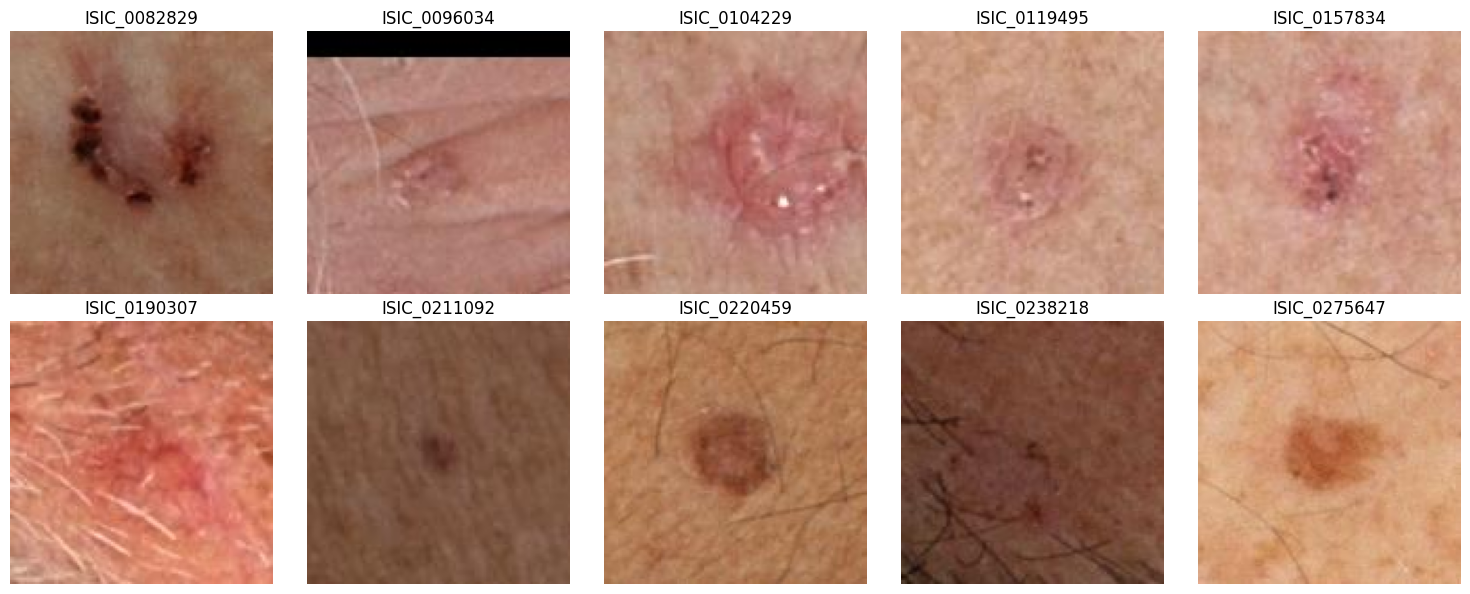

In [5]:
import matplotlib.pyplot as plt

# get first 10 isic_ids as sample and view them 
isic_ids = df_filtered['isic_id'].head(10)

# plot the images
plt.figure(figsize=(15, 6))
for i, isic_id in enumerate(isic_ids):
    image_path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = Image.open(image_path).convert("RGB")
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

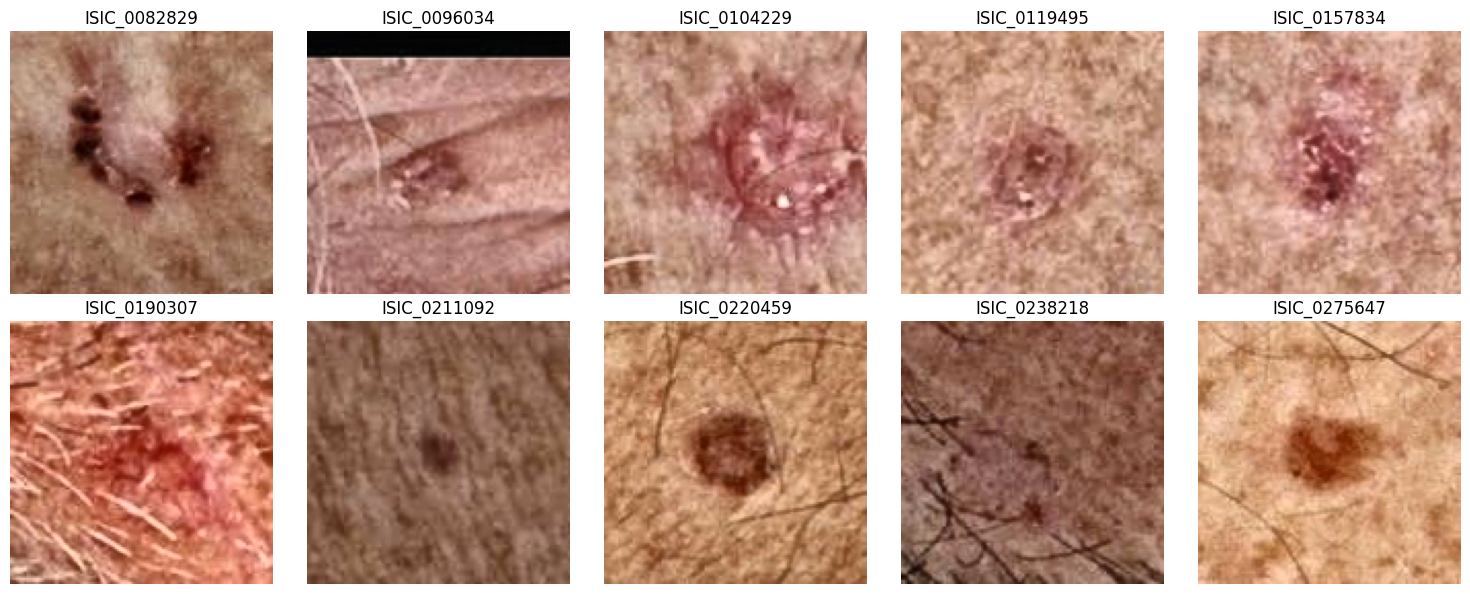

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/clahe_images'
os.makedirs(save_dir, exist_ok=True)

# Sample image IDs
isic_ids = df_filtered['isic_id'].head(10)

plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue  # skip if image not found

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    # Convert to YUV and apply CLAHE on the luminance channel
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    y_clahe = clahe.apply(y_channel)
    yuv[:, :, 0] = y_clahe

    # Convert back to RGB
    clahe_img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    # Save (convert back to BGR for OpenCV)
    save_path = os.path.join(save_dir, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(clahe_img, cv2.COLOR_RGB2BGR))

    # Plot
    plt.subplot(2, 5, i + 1)
    plt.imshow(clahe_img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

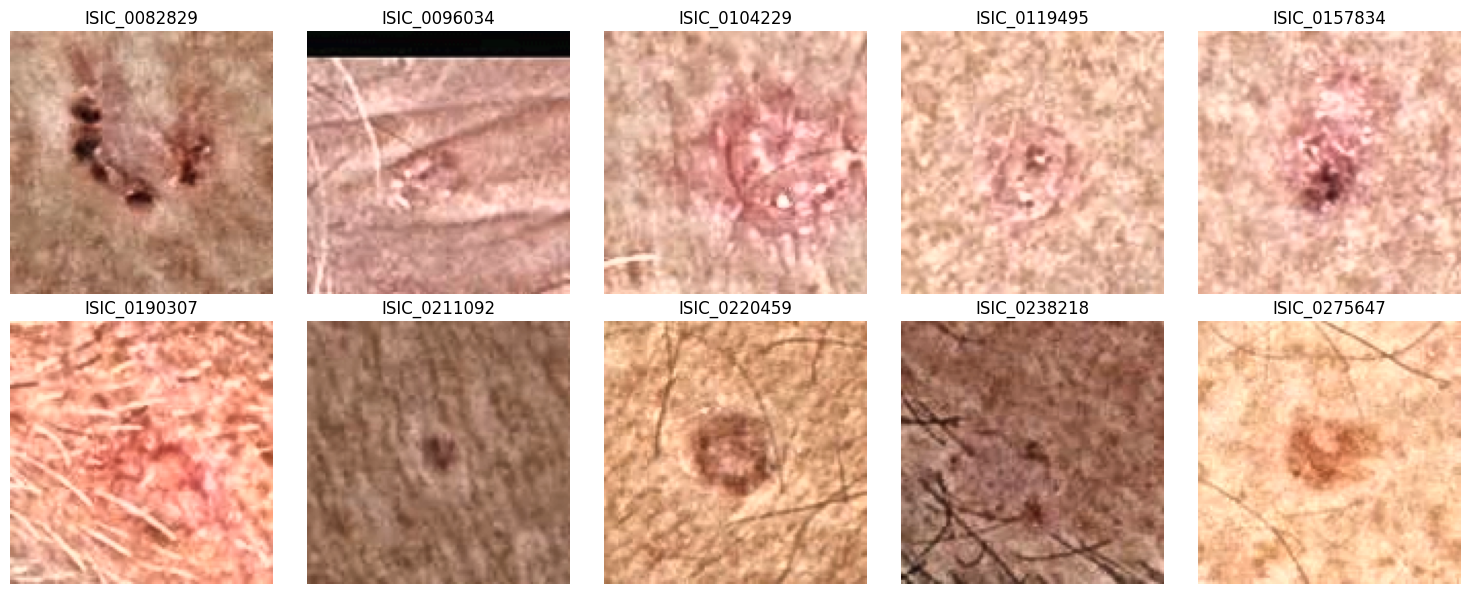

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

# Paths
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/clahe_images_lab'
os.makedirs(save_dir, exist_ok=True)

# Sample image IDs
isic_ids = df_filtered['isic_id'].head(10)

plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    # Convert to Lab color space
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    # Merge and convert back to RGB
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)

    # Save (convert to BGR for OpenCV)
    save_path = os.path.join(save_dir, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(img_clahe, cv2.COLOR_RGB2BGR))

    # Plot
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_clahe)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
!pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 23.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.8/315.8 kB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 16.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


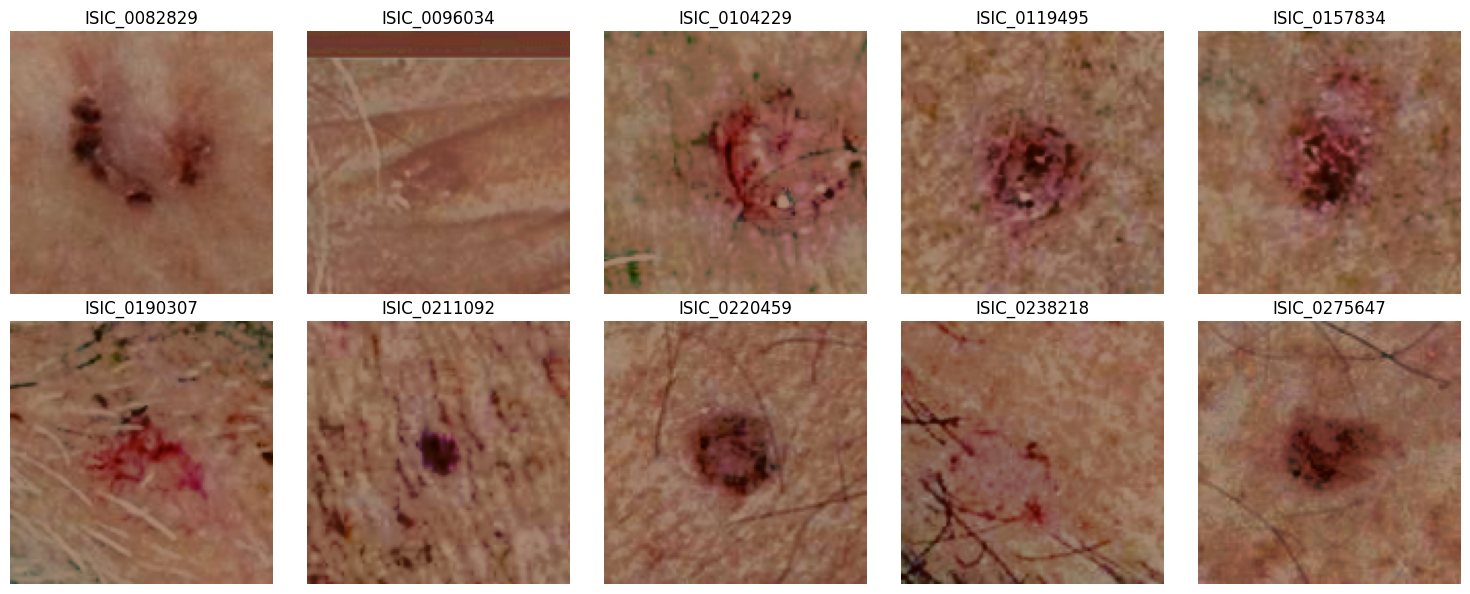

In [9]:
import os
import cv2
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

# Paths
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/histogram_matched_images'
os.makedirs(save_dir, exist_ok=True)

# Sample image IDs
isic_ids = df_filtered['isic_id'].head(10)

# Reference image (choose a well-lit image ID from your dataset)
reference_id = df_filtered['isic_id'].iloc[0]  # Use first image as reference
ref_path = os.path.join(image_dir, f"{reference_id}.jpg")
ref = cv2.imread(ref_path)
ref = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)
ref = cv2.resize(ref, (128, 128), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    # Match histogram to the reference image
    matched = match_histograms(img, ref, channel_axis=-1)

    # Save (convert to BGR for OpenCV)
    save_path = os.path.join(save_dir, f"{isic_id}_matched.jpg")
    cv2.imwrite(save_path, cv2.cvtColor((matched * 255).astype('uint8'), cv2.COLOR_RGB2BGR))

    # Plot
    plt.subplot(2, 5, i + 1)
    plt.imshow(matched)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

**without clahe**

In [10]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

def remove_hairs(img):
    """Apply DullRazor technique for hair removal on RGB image."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    bhg = cv2.GaussianBlur(blackhat, (3, 3), 0)
    _, mask = cv2.threshold(bhg, 10, 255, cv2.THRESH_BINARY)
    dst = cv2.inpaint(img, mask, 6, cv2.INPAINT_TELEA)
    return dst

image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/without_any'
os.makedirs(save_dir, exist_ok=True)

# keep all malignant and 10,000 benign
malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

# Store all records including augmented ones
new_records = []

def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))  # horizontal flip
    return aug_imgs

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))

    # ✅ Apply hair removal
    img = remove_hairs(img)

    # Convert back to BGR before saving with OpenCV
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Save processed image
    out_path = os.path.join(save_dir, f"{isic_id}.jpg")
    cv2.imwrite(out_path, img)
    new_records.append({'isic_id': isic_id, 'target': label})

    # Augment if malignant
    if label == 1:
        aug_imgs = augment_image(img)
        for i, aug_img in enumerate(aug_imgs):
            aug_id = f"{isic_id}_aug{i}"
            aug_path = os.path.join(save_dir, f"{aug_id}.jpg")
            cv2.imwrite(aug_path, aug_img)
            new_records.append({'isic_id': aug_id, 'target': 1})

# Create final DataFrame
df_filtered = pd.DataFrame(new_records).reset_index(drop=True)
print(f"Final dataset size: {len(df_filtered)}")
df_filtered.head()

100%|██████████| 10393/10393 [03:54<00:00, 44.34it/s]


Final dataset size: 12751


,isic_id,target
0,ISIC_0082829,1
1,ISIC_0082829_aug0,1
2,ISIC_0082829_aug1,1
3,ISIC_0082829_aug2,1
4,ISIC_0082829_aug3,1


In [11]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_df, val_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered["target"], random_state=42)

train_dataset = SkinLesionDataset(train_df, save_dir, transform)
val_dataset = SkinLesionDataset(val_df, save_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x  # raw logits

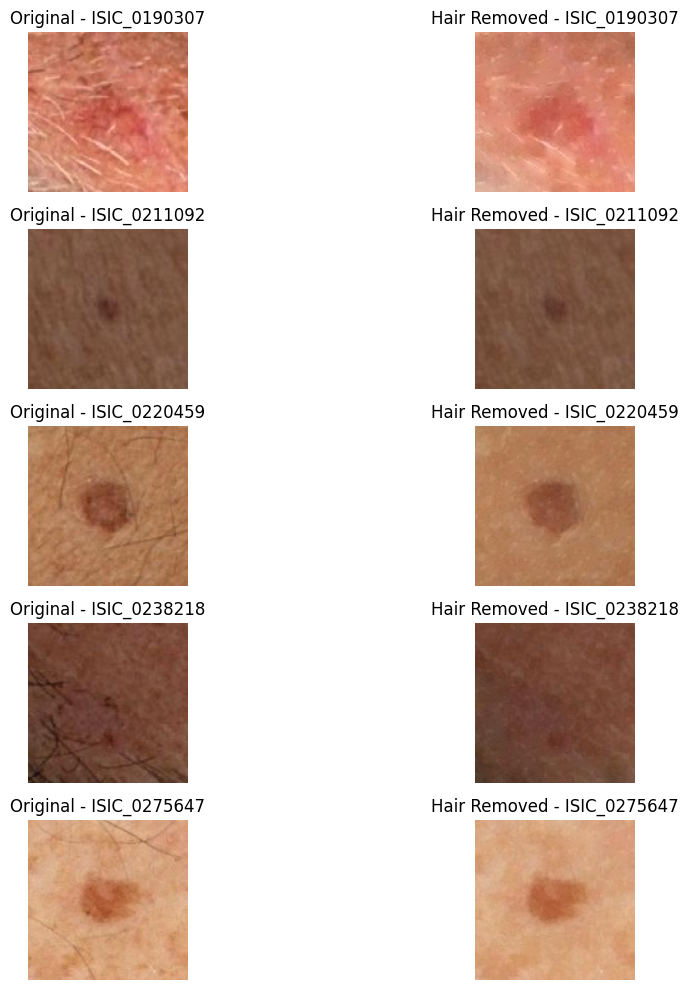

In [14]:
import matplotlib.pyplot as plt

def show_before_after(isic_ids, original_dir, processed_dir):
    """Display before/after images side by side."""
    plt.figure(figsize=(12, 10))
    for i, isic_id in enumerate(isic_ids):
        # Load original
        orig_path = os.path.join(original_dir, f"{isic_id}.jpg")
        orig_img = cv2.imread(orig_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        # Load processed
        proc_path = os.path.join(processed_dir, f"{isic_id}.jpg")
        proc_img = cv2.imread(proc_path)
        proc_img = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)

        # Show original
        plt.subplot(len(isic_ids), 2, 2 * i + 1)
        plt.imshow(orig_img)
        plt.title(f"Original - {isic_id}")
        plt.axis("off")

        # Show processed
        plt.subplot(len(isic_ids), 2, 2 * i + 2)
        plt.imshow(proc_img)
        plt.title(f"Hair Removed - {isic_id}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Example: Select 5 image IDs from your df_filtered
sample_ids = df_filtered[df_filtered["isic_id"].str.contains("aug") == False]["isic_id"].iloc[5:10].tolist()

# Set your original and processed image folders
original_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
processed_dir = '/kaggle/working/without_any'  # Or the directory with hair-removed images

# Display before-after comparisons
show_before_after(sample_ids, original_dir, processed_dir)

In [15]:
import torch
import torch.nn as nn

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN()
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
import torch.optim as optim

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.8)

In [16]:
print("📊 Image count by class (before training):")
print(df_filtered['target'].value_counts())

📊 Image count by class (before training):
target
0    10000
1     2751
Name: count, dtype: int64


In [17]:
from sklearn.metrics import accuracy_score
import torch

for epoch in range(5):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        # Compute training accuracy
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        train_preds.extend(preds.flatten())
        train_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            val_preds.extend(preds.flatten())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Loss = 0.4702, Train Acc = 0.7998, Val Loss = 0.4036, Val Acc = 0.8248


KeyboardInterrupt: 

Epoch 1: Train Loss = 0.4100, Train Acc = 0.8288, Val Loss = 0.3499, Val Acc = 0.8648

Epoch 2: Train Loss = 0.3448, Train Acc = 0.8594, Val Loss = 0.3097, Val Acc = 0.8753

Epoch 3: Train Loss = 0.3385, Train Acc = 0.8654, Val Loss = 0.3027, Val Acc = 0.8851

Epoch 4: Train Loss = 0.3320, Train Acc = 0.8671, Val Loss = 0.3041, Val Acc = 0.8753

Epoch 5: Train Loss = 0.3178, Train Acc = 0.8720, Val Loss = 0.2887, Val Acc = 0.8828

clahe Normal

In [54]:
import numpy as np
import cv2

def remove_hairs_v2(img):
    """
    Improved version of custom hair removal based on morphology, contour masking,
    and mean color thresholding. 
    Returns cleaned RGB image.
    """
    img = img.copy()
    kernel = np.ones((15,15), np.uint8)

    # Step 1: Morphological closing and blur to suppress hair
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=2)
    blurred = cv2.blur(closed, (15,15))

    # Step 2: Grayscale + OTSU binarization
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Step 3: Find largest contour (likely skin region)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img  # Return original if no contour

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest_contour], -1, 255, -1)

    # Step 4: Get mean color of skin region
    mean_color = cv2.mean(img, mask=mask)[:3]  # Ignore alpha
    mean_color = tuple(map(int, mean_color))

    # Step 5: Create final result — replace low color pixels inside region
    result = img.copy()
    h, w = img.shape[:2]
    for y in range(h):
        for x in range(w):
            if mask[y, x]:  # only inside the contour
                b, g, r = result[y, x]
                if r < mean_color[2]*0.8 or g < mean_color[1]*0.8 or b < mean_color[0]*0.8:
                    result[y, x] = mean_color

    return result

In [55]:
import cv2
import numpy as np

def remove_hairs_dullrazor(img):
    """
    Advanced hair removal using morphological black-hat and inpainting (DullRazor).
    Input: RGB image (uint8)
    Output: Hair-removed RGB image
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Step 1: Morphological black-hat to detect hair
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Step 2: Threshold the blackhat image to get the hair mask
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Step 3: Dilate the hair mask slightly to catch full hair strands
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)

    # Step 4: Inpaint the image in RGB
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)

    return inpainted

In [56]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

def apply_clahe_yuv(img):
    """Apply CLAHE to the Y channel of an RGB image."""
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

def augment_image(img):
    """Return rotated and flipped versions of the image."""
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))  # Horizontal flip
    return aug_imgs

# === Setup Paths ===
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/clahe_normal'
os.makedirs(save_dir, exist_ok=True)

# === Load and Filter DataFrame ===
malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

# === Process and Save Images ===
new_records = []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")

    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Failed to read: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # ✅ Hair removal and CLAHE
    img = remove_hairs_v2(img)
    img = remove_hairs_dullrazor(img)

    img = apply_clahe_yuv(img)

    # Save processed original
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})

    # Augment if malignant
    if label == 1:
        aug_imgs = augment_image(img)
        for i, aug_img in enumerate(aug_imgs):
            aug_id = f"{isic_id}_aug{i}"
            aug_path = os.path.join(save_dir, f"{aug_id}.jpg")
            cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            new_records.append({'isic_id': aug_id, 'target': 1})

# === Final DataFrame ===
df_filtered = pd.DataFrame(new_records).reset_index(drop=True)
print(f"✅ Final dataset size: {len(df_filtered)}")
df_filtered.head()

100%|██████████| 10393/10393 [18:58<00:00,  9.13it/s]


✅ Final dataset size: 12751


,isic_id,target
0,ISIC_0082829,1
1,ISIC_0082829_aug0,1
2,ISIC_0082829_aug1,1
3,ISIC_0082829_aug2,1
4,ISIC_0082829_aug3,1


In [57]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_df, val_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered["target"], random_state=42)

train_dataset = SkinLesionDataset(train_df, save_dir, transform)
val_dataset = SkinLesionDataset(val_df, save_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [58]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x  # raw logits

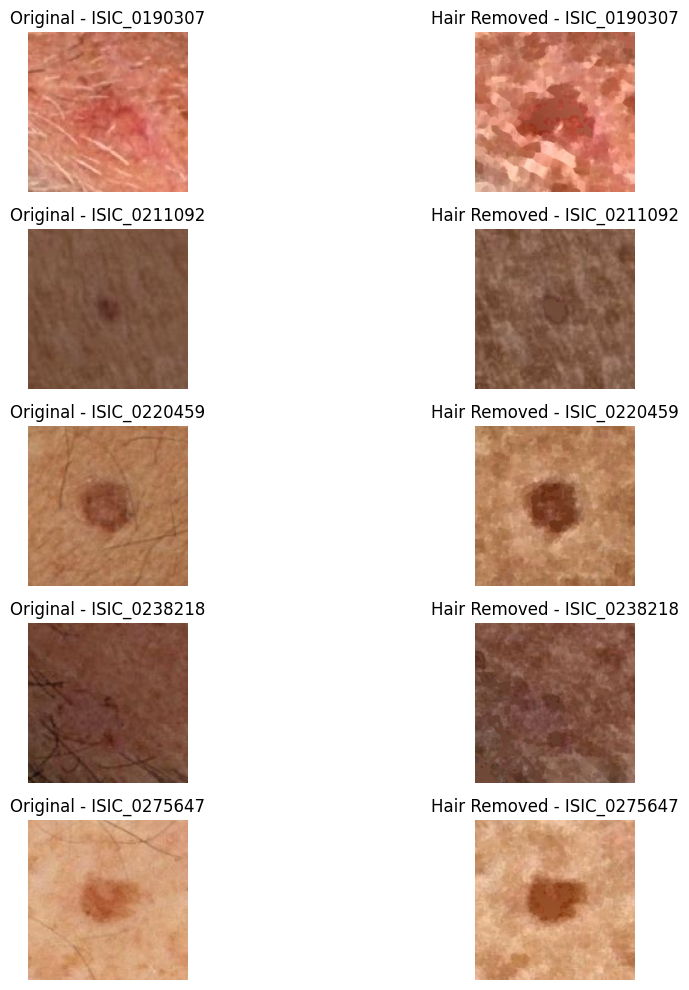

In [60]:
import matplotlib.pyplot as plt

def show_before_after(isic_ids, original_dir, processed_dir):
    """Display before/after images side by side."""
    plt.figure(figsize=(12, 10))
    for i, isic_id in enumerate(isic_ids):
        # Load original
        orig_path = os.path.join(original_dir, f"{isic_id}.jpg")
        orig_img = cv2.imread(orig_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        # Load processed
        proc_path = os.path.join(processed_dir, f"{isic_id}.jpg")
        proc_img = cv2.imread(proc_path)
        proc_img = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)

        # Show original
        plt.subplot(len(isic_ids), 2, 2 * i + 1)
        plt.imshow(orig_img)
        plt.title(f"Original - {isic_id}")
        plt.axis("off")

        # Show processed
        plt.subplot(len(isic_ids), 2, 2 * i + 2)
        plt.imshow(proc_img)
        plt.title(f"Hair Removed - {isic_id}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Example: Select 5 image IDs from your df_filtered
sample_ids = df_filtered[df_filtered["isic_id"].str.contains("aug") == False]["isic_id"].iloc[5:10].tolist()

# Set your original and processed image folders
original_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
processed_dir = '/kaggle/working/clahe_normal'  # Or the directory with hair-removed images

# Display before-after comparisons
show_before_after(sample_ids, original_dir, processed_dir)

In [61]:
print("📊 Image count by class (before training):")
print(df_filtered['target'].value_counts())

📊 Image count by class (before training):
target
0    10000
1     2751
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score
import torch

scheduler.step()

for epoch in range(5):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        # Compute training accuracy
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        train_preds.extend(preds.flatten())
        train_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            val_preds.extend(preds.flatten())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Loss = 0.3349, Train Acc = 0.8621, Val Loss = 0.3104, Val Acc = 0.8734
Epoch 2: Train Loss = 0.3329, Train Acc = 0.8662, Val Loss = 0.3105, Val Acc = 0.8663


Epoch 1: Train Loss = 0.3155, Train Acc = 0.8730, Val Loss = 0.2886, Val Acc = 0.8840

Epoch 2: Train Loss = 0.2888, Train Acc = 0.8775, Val Loss = 0.2858, Val Acc = 0.8844

Epoch 3: Train Loss = 0.2792, Train Acc = 0.8812, Val Loss = 0.2688, Val Acc = 0.8883

Epoch 4: Train Loss = 0.2645, Train Acc = 0.8864, Val Loss = 0.2644, Val Acc = 0.8910

Epoch 5: Train Loss = 0.2472, Train Acc = 0.8962, Val Loss = 0.2585, Val Acc = 0.8906